In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
import os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

os.makedirs('data/processed/', exist_ok=True)
print("=" * 60)
print("TASK 1: DATA PREPROCESSING AND EXPLORATION")
print("=" * 60)
print("Directory created: data/processed/")

TASK 1: DATA PREPROCESSING AND EXPLORATION
Directory created: data/processed/


In [31]:
start_date = '2015-01-01'
end_date = '2026-06-30'
tickers = ['TSLA', 'BND', 'SPY']

def fetch_data(ticker, start, end):
    print(f"Fetching data for {ticker}...")
    data = yf.download(ticker, start=start, end=end, progress=False)
    return data

data_dict = {}
for ticker in tickers:
    data_dict[ticker] = fetch_data(ticker, start_date, end_date)

for ticker, data in data_dict.items():
    print(f"\n{ticker} Data Shape: {data.shape}")
    print(f"Date Range: {data.index.min()} to {data.index.max()}")
    print(f"Columns: {data.columns.tolist()}")

Fetching data for TSLA...
Fetching data for BND...
Fetching data for SPY...

TSLA Data Shape: (2888, 5)
Date Range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Columns: [('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]

BND Data Shape: (2888, 5)
Date Range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Columns: [('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND')]

SPY Data Shape: (2888, 5)
Date Range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Columns: [('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


In [32]:
def clean_data(data_dict):
    cleaned_data = {}
    for ticker, df in data_dict.items():
        df_clean = df.copy()
        df_clean.reset_index(inplace=True)

        if df_clean.columns[0] == 'index':
            df_clean.rename(columns={'index': 'Date'}, inplace=True)
        elif df_clean.columns[0] == 'Date':
            pass
        else:
            df_clean.rename(columns={df_clean.columns[0]: 'Date'}, inplace=True)

        df_clean['Ticker'] = ticker

        missing = df_clean.isnull().sum()
        print(f"\n{ticker} Missing Values:")
        print(missing[missing > 0] if any(missing > 0) else "No missing values")

        df_clean = df_clean.ffill().bfill()
        cleaned_data[ticker] = df_clean

    return cleaned_data

cleaned_data = clean_data(data_dict)

def combine_data(cleaned_data):
    combined = pd.concat(cleaned_data.values(), ignore_index=True)
    return combined

combined_data = combine_data(cleaned_data)
print(f"\nCombined Data Shape: {combined_data.shape}")
print("\nFirst 5 rows of combined data:")
print(combined_data.head())

print("\nData Types:")
print(combined_data.dtypes)

print("\nAll columns in combined_data:")
print(combined_data.columns.tolist())

print("\nBasic Statistics for TSLA:")
tsla_subset = combined_data[combined_data['Ticker']=='TSLA']
available_cols = tsla_subset.columns.tolist()
print(f"Available columns for TSLA: {available_cols}")

price_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
existing_price_cols = [col for col in price_cols if col in available_cols]

if existing_price_cols:
    print(tsla_subset[existing_price_cols].describe())
else:
    print("No expected price columns found. Showing all numeric columns:")
    numeric_cols = tsla_subset.select_dtypes(include=[np.number]).columns.tolist()
    print(tsla_subset[numeric_cols].describe())


TSLA Missing Values:
No missing values

BND Missing Values:
No missing values

SPY Missing Values:
No missing values

Combined Data Shape: (8664, 17)

First 5 rows of combined data:
Price        Date      Close       High        Low       Open      Volume  \
Ticker                  TSLA       TSLA       TSLA       TSLA        TSLA   
0      2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000.0   
1      2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500.0   
2      2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500.0   
3      2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000.0   
4      2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500.0   

Price  Ticker Close High Low Open Volume Close High Low Open Volume  
Ticker          BND  BND BND  BND    BND   SPY  SPY SPY  SPY    SPY  
0        TSLA   NaN  NaN NaN  NaN    NaN   NaN  NaN NaN  NaN    NaN  
1        TSLA   NaN  NaN NaN  NaN    NaN   NaN  NaN NaN  NaN    NaN

In [33]:
tsla_data = cleaned_data['TSLA'].copy()
bnd_data = cleaned_data['BND'].copy()
spy_data = cleaned_data['SPY'].copy()

tsla_data.set_index('Date', inplace=True)
bnd_data.set_index('Date', inplace=True)
spy_data.set_index('Date', inplace=True)

tsla_data.index = pd.to_datetime(tsla_data.index)
bnd_data.index = pd.to_datetime(bnd_data.index)
spy_data.index = pd.to_datetime(spy_data.index)

def get_close_column(df):
    possible_names = ['Close', 'close', 'Adj Close', 'Adj_Close', 'adj close']
    for name in possible_names:
        if name in df.columns:
            return name
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        return numeric_cols[0]
    return None

close_col_tsla = get_close_column(tsla_data)
close_col_bnd = get_close_column(bnd_data)
close_col_spy = get_close_column(spy_data)

print(f"TSLA Close column: {close_col_tsla}")
print(f"BND Close column: {close_col_bnd}")
print(f"SPY Close column: {close_col_spy}")

TSLA Close column: Close
BND Close column: Close
SPY Close column: Close


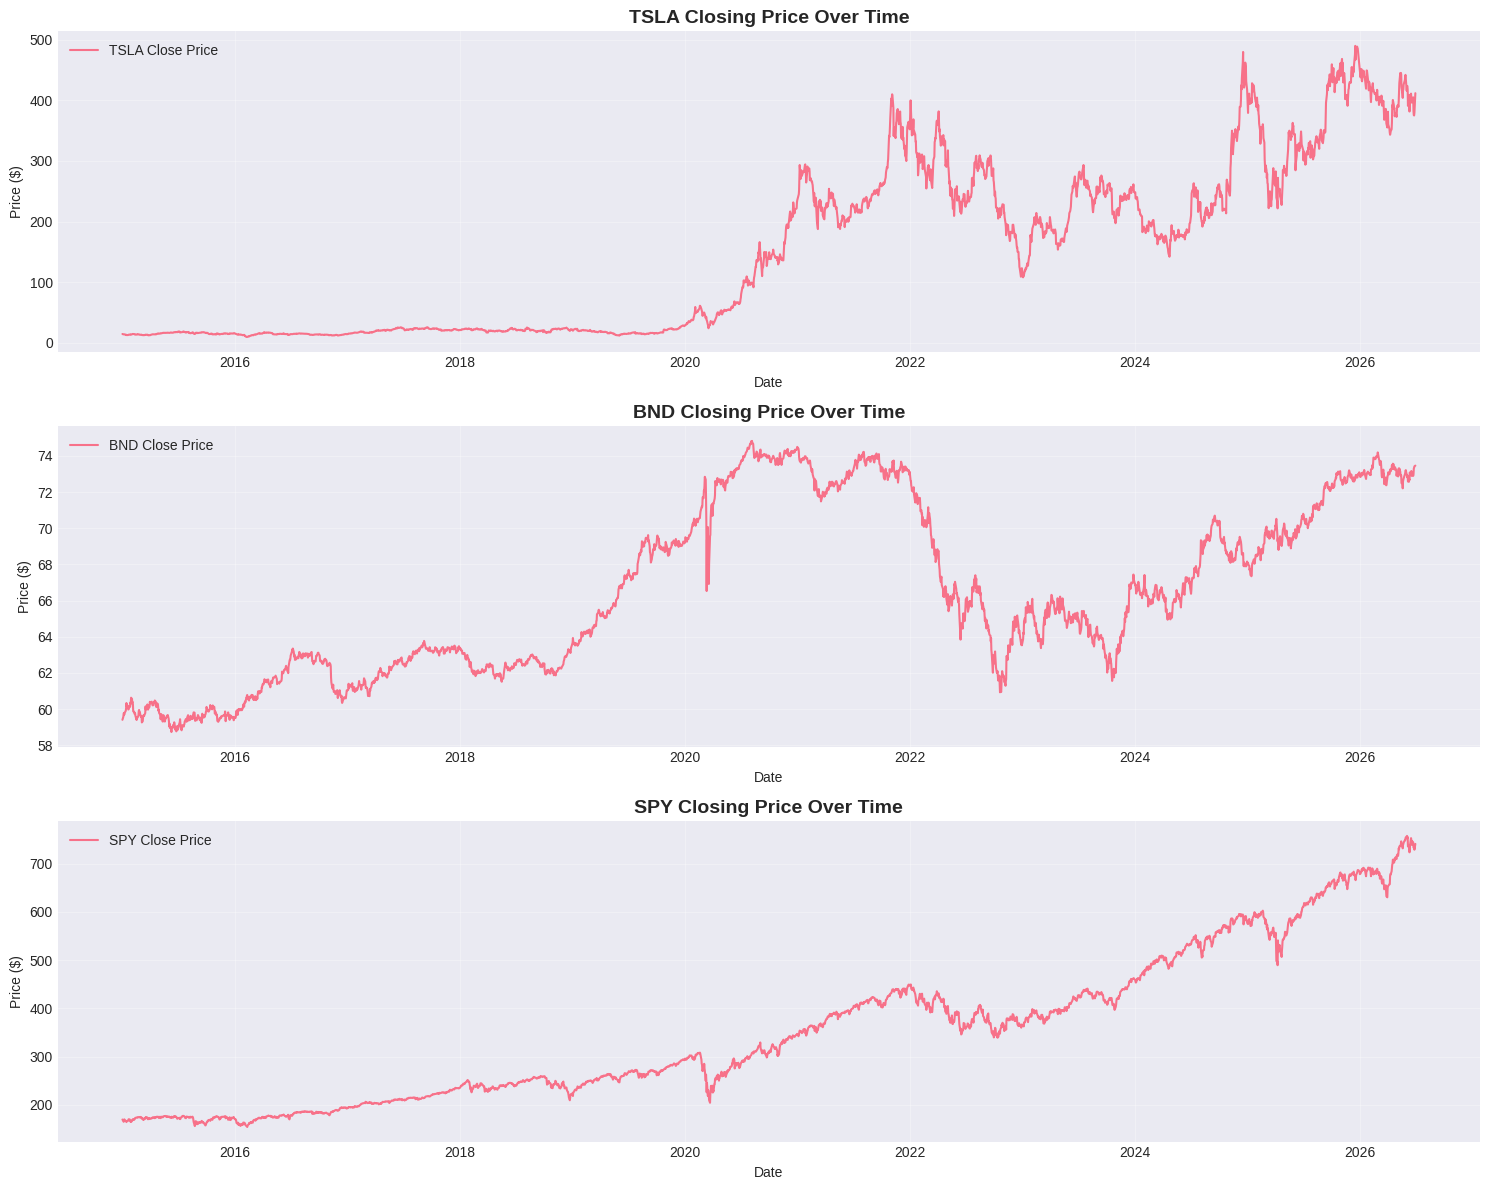

Saved: data/processed/closing_prices.png


In [34]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for idx, (ticker, data, close_col) in enumerate([('TSLA', tsla_data, close_col_tsla),
                                                   ('BND', bnd_data, close_col_bnd),
                                                   ('SPY', spy_data, close_col_spy)]):
    if close_col:
        axes[idx].plot(data.index, data[close_col], label=f'{ticker} Close Price', linewidth=1.5)
        axes[idx].set_title(f'{ticker} Closing Price Over Time', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel('Price ($)')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'No close price data for {ticker}',
                      horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('data/processed/closing_prices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data/processed/closing_prices.png")

In [35]:
def calculate_returns(df, close_col):
    if close_col:
        df['Returns'] = df[close_col].pct_change()
    else:
        df['Returns'] = np.nan

calculate_returns(tsla_data, close_col_tsla)
calculate_returns(bnd_data, close_col_bnd)
calculate_returns(spy_data, close_col_spy)

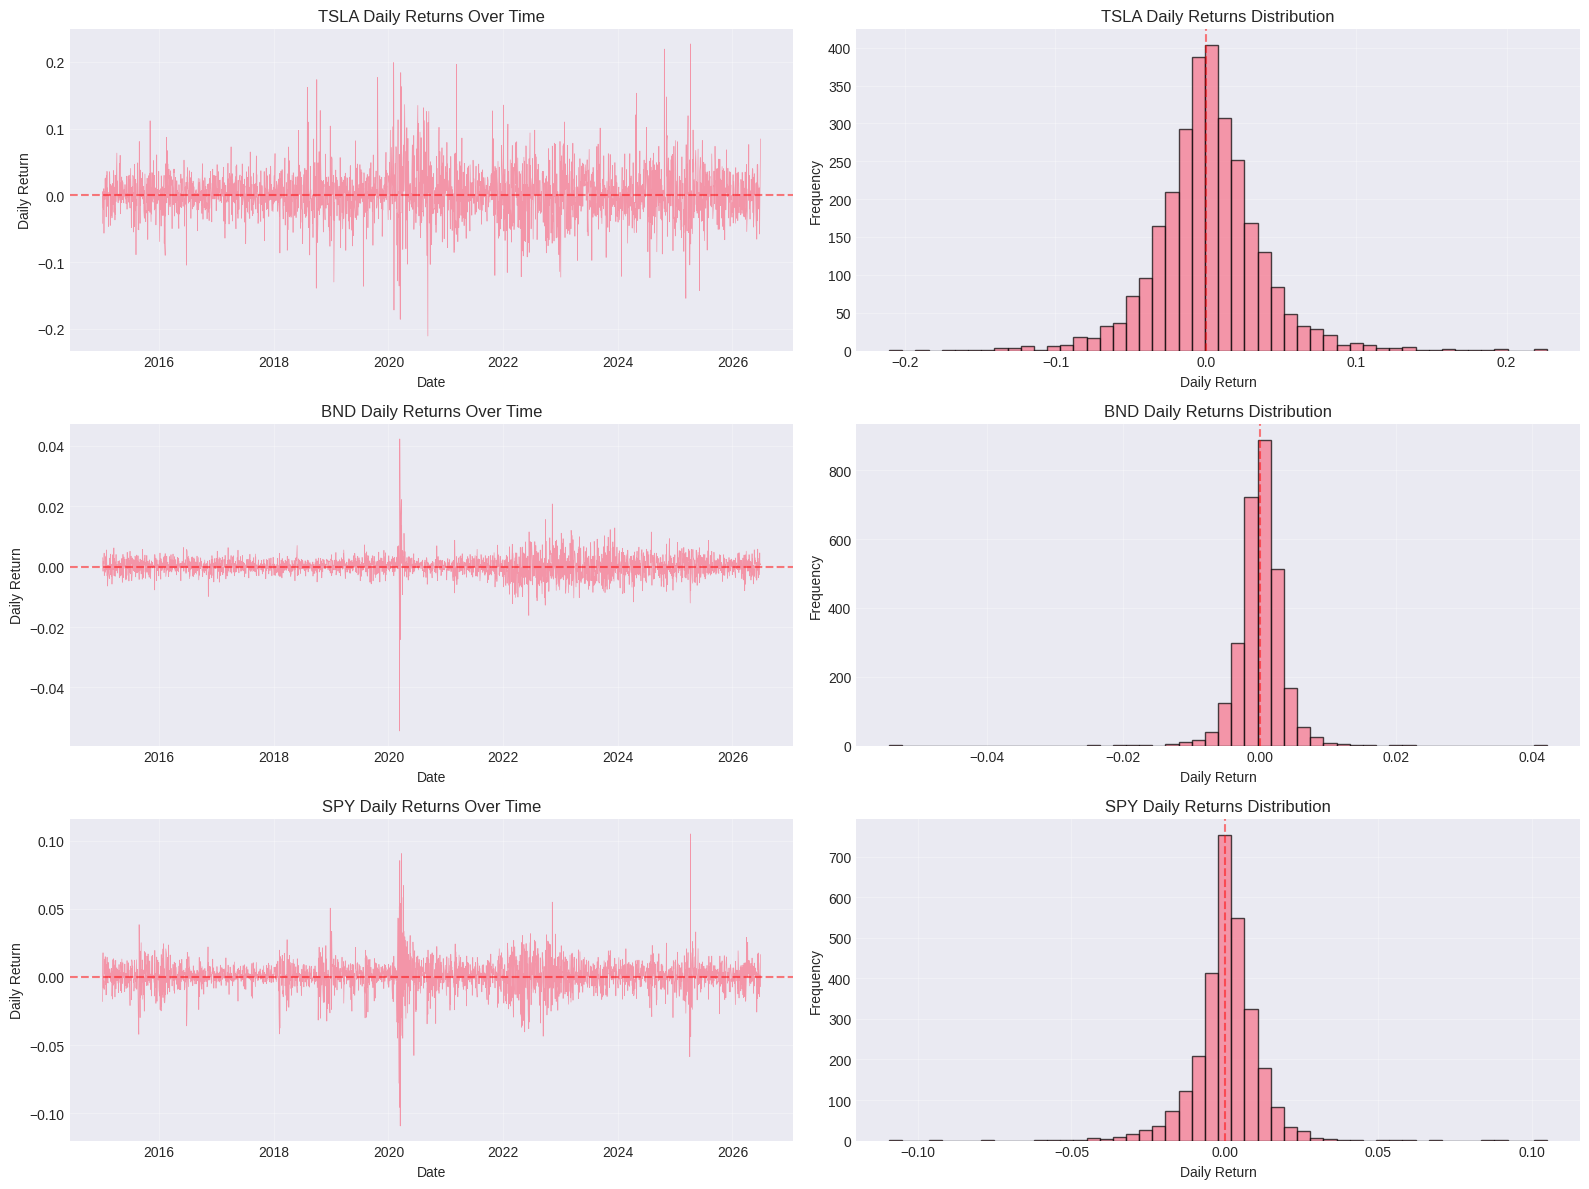

Saved: data/processed/daily_returns.png


In [36]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for idx, (ticker, data) in enumerate([('TSLA', tsla_data), ('BND', bnd_data), ('SPY', spy_data)]):
    if 'Returns' in data.columns and not data['Returns'].isna().all():
        axes[idx, 0].plot(data.index, data['Returns'], linewidth=0.5, alpha=0.7)
        axes[idx, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[idx, 0].set_title(f'{ticker} Daily Returns Over Time', fontsize=12)
        axes[idx, 0].set_xlabel('Date')
        axes[idx, 0].set_ylabel('Daily Return')
        axes[idx, 0].grid(True, alpha=0.3)

        axes[idx, 1].hist(data['Returns'].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[idx, 1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
        axes[idx, 1].set_title(f'{ticker} Daily Returns Distribution', fontsize=12)
        axes[idx, 1].set_xlabel('Daily Return')
        axes[idx, 1].set_ylabel('Frequency')
        axes[idx, 1].grid(True, alpha=0.3)
    else:
        axes[idx, 0].text(0.5, 0.5, f'No returns data for {ticker}',
                         horizontalalignment='center', verticalalignment='center')
        axes[idx, 1].text(0.5, 0.5, f'No returns data for {ticker}',
                         horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('data/processed/daily_returns.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data/processed/daily_returns.png")

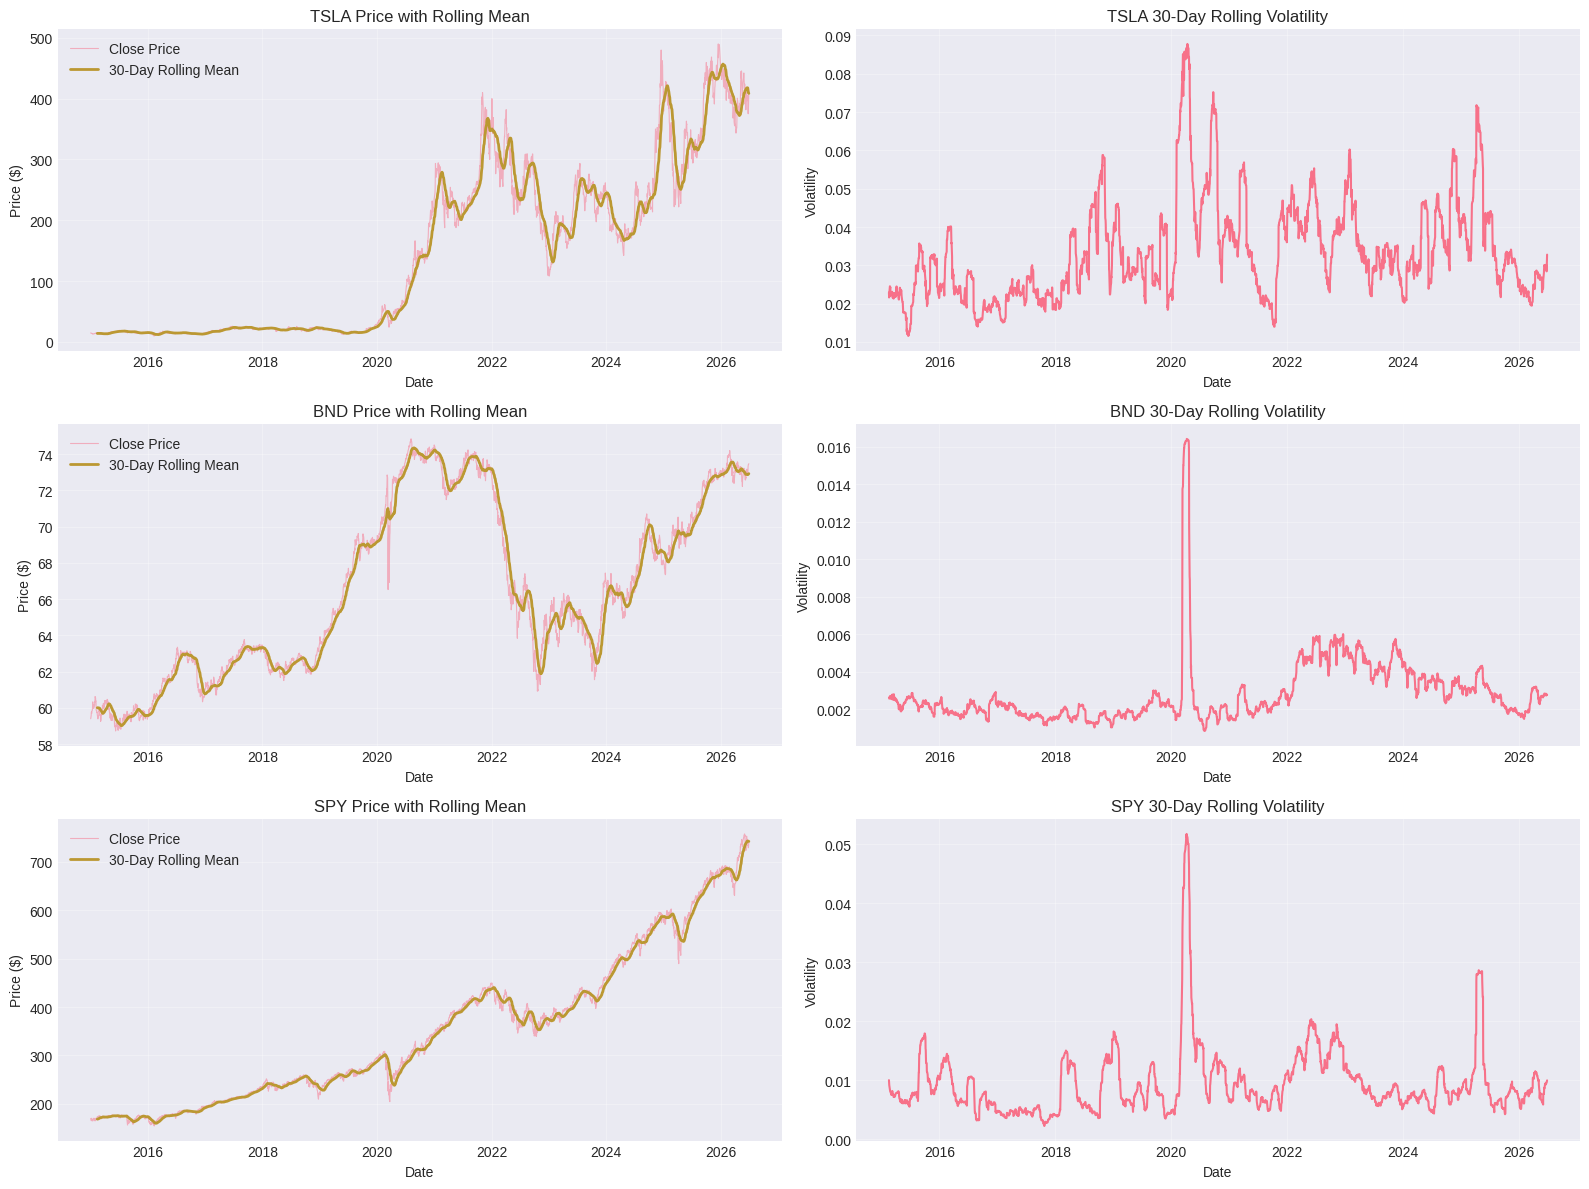

Saved: data/processed/rolling_statistics.png


In [37]:
window = 30

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for idx, (ticker, data) in enumerate([('TSLA', tsla_data), ('BND', bnd_data), ('SPY', spy_data)]):
    close_col = get_close_column(data)

    if close_col and 'Returns' in data.columns and not data['Returns'].isna().all():
        data['Rolling_Mean'] = data[close_col].rolling(window=window).mean()
        axes[idx, 0].plot(data.index, data[close_col], label='Close Price', alpha=0.5, linewidth=0.8)
        axes[idx, 0].plot(data.index, data['Rolling_Mean'], label=f'{window}-Day Rolling Mean', linewidth=2)
        axes[idx, 0].set_title(f'{ticker} Price with Rolling Mean', fontsize=12)
        axes[idx, 0].set_xlabel('Date')
        axes[idx, 0].set_ylabel('Price ($)')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)

        data['Rolling_Std'] = data['Returns'].rolling(window=window).std()
        axes[idx, 1].plot(data.index, data['Rolling_Std'], linewidth=1.5)
        axes[idx, 1].set_title(f'{ticker} {window}-Day Rolling Volatility', fontsize=12)
        axes[idx, 1].set_xlabel('Date')
        axes[idx, 1].set_ylabel('Volatility')
        axes[idx, 1].grid(True, alpha=0.3)
    else:
        axes[idx, 0].text(0.5, 0.5, f'No data for {ticker}',
                         horizontalalignment='center', verticalalignment='center')
        axes[idx, 1].text(0.5, 0.5, f'No data for {ticker}',
                         horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('data/processed/rolling_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data/processed/rolling_statistics.png")

In [38]:
def detect_outliers(data, column='Returns', threshold=3):
    if column not in data.columns or data[column].isna().all():
        return pd.DataFrame()
    mean = data[column].mean()
    std = data[column].std()
    if std == 0:
        return pd.DataFrame()
    z_scores = (data[column] - mean) / std
    outliers = data[abs(z_scores) > threshold]
    return outliers

for ticker, data in [('TSLA', tsla_data), ('BND', bnd_data), ('SPY', spy_data)]:
    outliers = detect_outliers(data)
    print(f"{ticker} - Number of outliers in returns: {len(outliers)}")
    if len(outliers) > 0:
        print(f"Most extreme outlier: {outliers['Returns'].min():.4f} to {outliers['Returns'].max():.4f}")
        close_col = get_close_column(data)
        if close_col:
            print(outliers[[close_col, 'Returns']].head())
        print()

TSLA - Number of outliers in returns: 46
Most extreme outlier: -0.2106 to 0.2269
Price           Close   Returns
Ticker           TSLA          
Date                           
2015-11-04  15.442000  0.111735
2018-08-02  23.302668  0.161880
2018-08-07  25.304667  0.109886
2018-09-28  17.651333 -0.139015
2018-10-01  20.713333  0.173471

BND - Number of outliers in returns: 33
Most extreme outlier: -0.0544 to 0.0422
Price           Close   Returns
Ticker            BND          
Date                           
2020-03-10  71.712822 -0.013444
2020-03-11  70.354591 -0.018940
2020-03-12  66.528328 -0.054385
2020-03-13  69.335899  0.042201
2020-03-16  70.064735  0.010512

SPY - Number of outliers in returns: 39
Most extreme outlier: -0.1094 to 0.1050
Price            Close   Returns
Ticker             SPY          
Date                            
2015-08-24  157.992950 -0.042107
2015-08-26  162.128250  0.038393
2016-06-24  173.122574 -0.035909
2018-02-05  231.705261 -0.041823
2018-02-08  22

In [39]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    print(f'\n{title} Augmented Dickey-Fuller Test:')
    print('-' * 50)
    series_clean = series.dropna()
    if len(series_clean) < 10:
        print("Not enough data for ADF test")
        return False
    result = adfuller(series_clean, autolag='AIC')

    labels = ['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for label, value in zip(labels, result[:4]):
        print(f'{label}: {value:.6f}' if isinstance(value, float) else f'{label}: {value}')

    print('\nCritical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')

    if result[1] <= 0.05:
        print("\nResult: The series is STATIONARY (reject H0)")
        return True
    else:
        print("\nResult: The series is NON-STATIONARY (fail to reject H0)")
        return False

print("Stationarity Test for Closing Prices:")
print("=" * 60)
for ticker, data in [('TSLA', tsla_data), ('BND', bnd_data), ('SPY', spy_data)]:
    close_col = get_close_column(data)
    if close_col:
        adf_test(data[close_col], ticker)
    else:
        print(f"\n{ticker}: No close price column found")

print("\n\nStationarity Test for Daily Returns:")
print("=" * 60)
for ticker, data in [('TSLA', tsla_data), ('BND', bnd_data), ('SPY', spy_data)]:
    if 'Returns' in data.columns and not data['Returns'].isna().all():
        adf_test(data['Returns'], f'{ticker} Returns')
    else:
        print(f"\n{ticker}: No returns data found")

Stationarity Test for Closing Prices:

TSLA Augmented Dickey-Fuller Test:
--------------------------------------------------
ADF Test Statistic: -1.069599
p-value: 0.727042
#Lags Used: 27
Number of Observations Used: 2860

Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567

Result: The series is NON-STATIONARY (fail to reject H0)

BND Augmented Dickey-Fuller Test:
--------------------------------------------------
ADF Test Statistic: -1.082712
p-value: 0.721917
#Lags Used: 13
Number of Observations Used: 2874

Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567

Result: The series is NON-STATIONARY (fail to reject H0)

SPY Augmented Dickey-Fuller Test:
--------------------------------------------------
ADF Test Statistic: 1.308943
p-value: 0.996659
#Lags Used: 9
Number of Observations Used: 2878

Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567

Result: The series is NON-STATIONARY (fail to reject H0)


Stationarity Test for Daily Returns:

TSLA Returns Augmented Dickey-Fulle

In [40]:
def calculate_risk_metrics(data, confidence_level=0.95):
    returns = data['Returns'].dropna()

    var = np.percentile(returns, (1 - confidence_level) * 100)
    cvar = returns[returns <= var].mean()

    risk_free_rate = 0.02
    excess_returns = returns.mean() * 252 - risk_free_rate
    volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = excess_returns / volatility if volatility != 0 else 0

    return {
        'VaR (95%)': var,
        'CVaR (95%)': cvar,
        'Annualized Return': returns.mean() * 252,
        'Annualized Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio
    }

print("Risk Metrics Summary:")
print("=" * 60)
metrics_dict = {}
for ticker, data in [('TSLA', tsla_data), ('BND', bnd_data), ('SPY', spy_data)]:
    metrics = calculate_risk_metrics(data)
    metrics_dict[ticker] = metrics
    print(f"\n{ticker}:")
    for metric, value in metrics.items():
        if metric in ['VaR (95%)', 'CVaR (95%)']:
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: {value:.4f}")

Risk Metrics Summary:

TSLA:
  VaR (95%): -0.0517
  CVaR (95%): -0.0786
  Annualized Return: 0.4542
  Annualized Volatility: 0.5718
  Sharpe Ratio: 0.7595

BND:
  VaR (95%): -0.0048
  CVaR (95%): -0.0074
  Annualized Return: 0.0200
  Annualized Volatility: 0.0531
  Sharpe Ratio: -0.0008

SPY:
  VaR (95%): -0.0167
  CVaR (95%): -0.0268
  Annualized Return: 0.1443
  Annualized Volatility: 0.1765
  Sharpe Ratio: 0.7042


In [41]:
tsla_data.to_csv('data/processed/TSLA_processed.csv')
bnd_data.to_csv('data/processed/BND_processed.csv')
spy_data.to_csv('data/processed/SPY_processed.csv')
combined_data.to_csv('data/processed/all_assets_combined.csv', index=False)

metrics_df = pd.DataFrame(metrics_dict).T
metrics_df.to_csv('data/processed/risk_metrics.csv')

print("Data saved successfully!")
print(f"TSLA data shape: {tsla_data.shape}")
print(f"BND data shape: {bnd_data.shape}")
print(f"SPY data shape: {spy_data.shape}")
print("\nTask 1 Complete!")

Data saved successfully!
TSLA data shape: (2888, 9)
BND data shape: (2888, 9)
SPY data shape: (2888, 9)

Task 1 Complete!


In [42]:
from google.colab import files

import os
print("Files in data/processed/:")
for file in os.listdir('data/processed/'):
    print(f"  - {file}")
files_to_download = [
    'closing_prices.png',
    'daily_returns.png',
    'rolling_statistics.png',
    'TSLA_processed.csv',
    'BND_processed.csv',
    'SPY_processed.csv',
    'all_assets_combined.csv',
    'risk_metrics.csv'
]

for file in files_to_download:
    file_path = f'data/processed/{file}'
    if os.path.exists(file_path):
        print(f"Downloading: {file}")
        files.download(file_path)
    else:
        print(f"File not found: {file}")

Files in data/processed/:
  - rolling_statistics.png
  - closing_prices.png
  - daily_returns.png
  - BND_processed.csv
  - TSLA_processed.csv
  - SPY_processed.csv
  - risk_metrics.csv
  - all_assets_combined.csv
Downloading: closing_prices.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: daily_returns.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: risk_metrics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>